In [1]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

import sys
sys.path.append('../')
import load_data

D = load_data.D
alphas = load_data.alphas
kfeks = load_data.kfeks
k_arevaloz = load_data.k_arevaloz
models = load_data.models

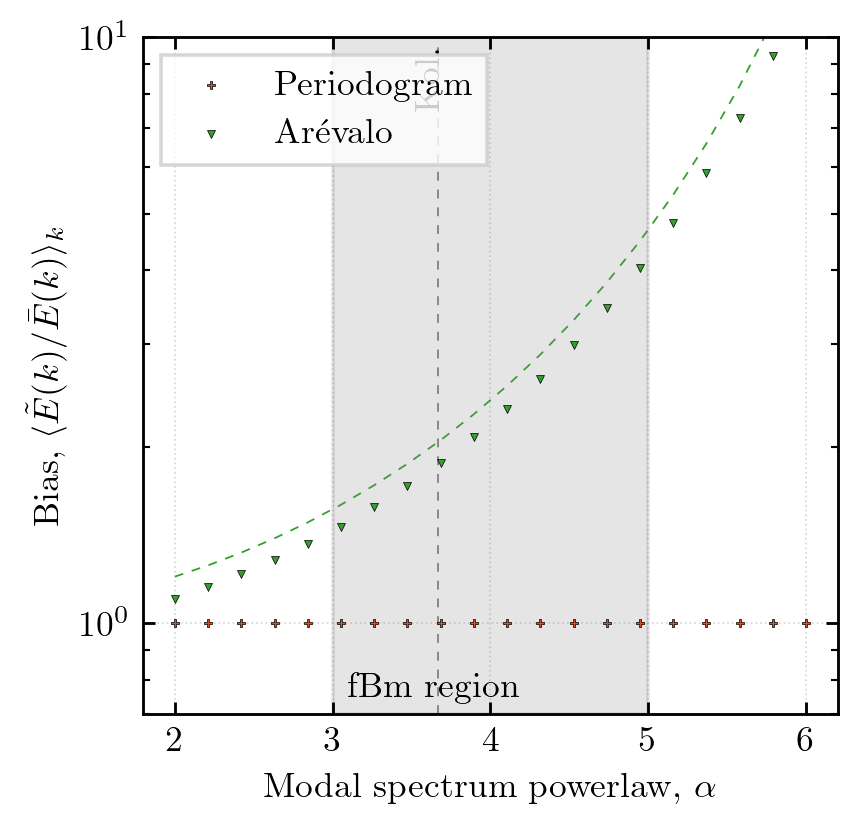

In [2]:
ek_avg = {}
for i, kfek in enumerate(kfeks):
    k, fek, w = kfek
    ek_avg[-alphas[i]] = (np.nanmean(fek/models[i][1]), 1.)

arevalo_avg = {}
for i, kfek in enumerate(k_arevaloz):
    k, fek = kfek
    arevalo_avg[-alphas[i]] = (np.nanmean(fek/models[i][1]), 1.)

c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for a in ek_avg.keys():
    ax.scatter(a, ek_avg[a][0], marker='P', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

for a in arevalo_avg.keys():
    ax.scatter(a, arevalo_avg[a][0], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')

from scipy.special import gamma
aa = -alphas
scaling = 2.**(-aa/2.) * (D+3.)**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
ax.plot(-alphas, scaling - 0., linewidth=0.5, color=c[2], linestyle=(0,(5,5)), zorder=0)

ax.scatter([], [], marker='P', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Periodogram')
ax.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Ar\'evalo')
ax.legend(fancybox=False, frameon=True, loc='upper left')

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=0.5, zorder=0)
ax.text(11./3.-0.15, 0.9, r'Kol.', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
ax.text(D+0.1, 0.025, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Bias, $\langle \\tilde{E}(k)/\\bar{E}(k) \\rangle_{k}$')
ax.set_xlabel('Modal spectrum powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')

#ax.set_ylim((-1.2, 5.1))

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')

ax.set_ylim((.7, 1e1))

#fig.subplots_adjust(wspace=0.05)
fig.savefig('plots/fbm_spectra_bias_%s.pdf' % D, transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/fbm_spectra_bias_%s.png' % D, transparent=True, bbox_inches='tight', pad_inches=0)
